# Лабораторна робота № 1. Веб-лічильник: пам'ять, диск, flame graph

Вовкотруб Олександр Віталійович, група ФБ-61мн.
КПІ ім. Ігоря Сікорського, ННФТІ, кафедра інформаційної безпеки.
Дисципліна «Проєктування високонавантажених систем», викладач Родіонов А. М.

Ноутбук аналізує виміри HTTP-лічильника, який зберігає значення в пам'яті
процесу або у файлі з `fsync` після кожного інкременту. Сервер і генератор
навантаження написані на Swift 6 (SwiftNIO), а тут лише читаються їхні
результати з `reports/data/*.csv`, рахуються медіани й будуються рисунки
для звіту. Наприкінці є жива перевірка: справжні бінарні файли запускаються
на зменшеному навантаженні.

## 0. Підготовка середовища

Корінь репозиторію шукаємо від поточної теки вгору до файла `Package.swift`,
тож ноутбук працює і зі своєї теки, і з кореня. Рисунки
зберігаються в `assets/` поруч із ноутбуком з числовими префіксами в порядку
звіту. `RUN_LIVE = False` вимикає розділ із запуском Swift-програм.

In [1]:
import io
import os
import re
import shutil
import subprocess
import tempfile
import time
import urllib.request
from contextlib import contextmanager
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, display


def find_root(start: Path) -> Path:
    for d in [start, *start.parents]:
        if (d / "Package.swift").is_file():
            return d
    raise FileNotFoundError("не знайдено Package.swift вище від " + str(start))


ROOT = find_root(Path.cwd().resolve())
# Тека ноутбука: поточна, якщо ноутбук запущено з неї, інакше його
# місце в репозиторії.
LAB = Path.cwd() if (Path.cwd() / "solution.ipynb").is_file() else next(
    p for p in (ROOT / "lab1", ROOT / "Labs" / "01-web-counter") if p.is_dir())
DATA = ROOT / "reports" / "data"
IMG = ROOT / "reports" / "img"
ASSETS = LAB / "assets"
ASSETS.mkdir(exist_ok=True)

RUN_LIVE = True

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Liberation Sans", "DejaVu Sans"],
    "font.size": 13,
    "axes.titlesize": 12,
    "axes.labelsize": 13,
    "legend.fontsize": 12,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "figure.dpi": 100,
})

# Один колір на одне сховище в усіх рисунках.
C_MEMORY = "#2a78d6"   # пам'ять
C_DISK = "#eb6834"     # диск, fsync на кожен інкремент
C_GROUP = "#1baf7a"    # диск, групування комітів
C_LIGHT = {C_MEMORY: "#9cc2ef", C_DISK: "#f6b79c"}


def save(fig, name: str) -> None:
    """Зберегти рисунок для звіту й показати його в ноутбуці."""
    fig.savefig(ASSETS / name, dpi=200, bbox_inches="tight")
    plt.show()
    print("збережено", (ASSETS / name).relative_to(ROOT))


def ua(x: float, digits: int = 0) -> str:
    """Число в українському записі: пробіл між тисячами, кома в дробі."""
    s = f"{x:,.{digits}f}"
    return s.replace(",", " ").replace(".", ",")


def excerpt(rel_path: str, start: str, lines: int) -> None:
    """Надрукувати фрагмент Swift-коду з номерами рядків, від рядка з `start`."""
    src = (ROOT / rel_path).read_text(encoding="utf-8").splitlines()
    first = next(i for i, line in enumerate(src) if start in line)
    print(f"// {rel_path}")
    for i in range(first, min(first + lines, len(src))):
        print(f"{i + 1:4d} | {src[i]}")


print("корінь репозиторію:", ROOT.name)
print("matplotlib", matplotlib.__version__, "| pandas", pd.__version__)

корінь репозиторію: HighLoadSystems
matplotlib 3.11.2 | pandas 3.0.6


## 1. Постановка

Сервер має два маршрути: `GET /inc` збільшує лічильник на 1, `GET /count`
повертає значення. Навантаження: 1, 2, 5 і 10 одночасних клієнтів, кожен
робить 10 000 запитів `/inc` послідовно (наступний лише після відповіді на
попередній). Для кожного запуску потрібні час, RPS і перевірка, що фінальне
значення дорівнює кількості клієнтів, помноженій на 10 000.

- Частина I: лічильник у пам'яті процесу.
- Частина II: лічильник у файлі, `fsync` після кожного інкременту.
- Частина III: flame graph сервера під навантаженням 10 клієнтів по 10 000 запитів.

Додатково досліджено, як підняти RPS обох варіантів, не порушуючи умов.

## 2. Реалізація

### Лічильник у пам'яті

`InMemoryCounterStore` тримає значення в `Atomic<Int>` з модуля
`Synchronization`. Інкремент є однією атомарною інструкцією без блокувань.

In [2]:
excerpt("Sources/CounterCore/InMemoryCounterStore.swift",
        "public final class InMemoryCounterStore", 33)

// Sources/CounterCore/InMemoryCounterStore.swift
   7 | public final class InMemoryCounterStore: CounterStore {
   8 |     private let counter = Atomic<Int>(0)
   9 | 
  10 |     public init() {}
  11 | 
  12 |     public func increment() async throws {
  13 |         incrementNow()
  14 |     }
  15 | 
  16 |     public func value() async throws -> Int {
  17 |         valueNow()
  18 |     }
  19 | 
  20 |     public func reset() async throws {
  21 |         resetNow()
  22 |     }
  23 | 
  24 |     public func incrementNow() {
  25 |         counter.add(1, ordering: .relaxed)
  26 |     }
  27 | 
  28 |     public func valueNow() -> Int {
  29 |         counter.load(ordering: .relaxed)
  30 |     }
  31 | 
  32 |     public func resetNow() {
  33 |         counter.store(0, ordering: .relaxed)
  34 |     }
  35 | }


### Лічильник на диску

`FileCounterStore` під `Mutex` читає значення (`pread`), записує нове
(`pwrite` 21 байта за зміщенням 0) і викликає `fsync`. Блокуючий ввід-вивід
іде в `NIOThreadPool`, щоб не зупиняти event loop'и. `Mutex` тримається на
весь час `fsync`, тому інкременти виконуються строго по одному.

In [3]:
excerpt("Sources/CounterCore/FileCounterStore.swift", "public func increment()", 8)
print()
excerpt("Sources/CounterCore/FileCounterStore.swift", "static func write(_ value", 4)

// Sources/CounterCore/FileCounterStore.swift
  50 |     public func increment() async throws {
  51 |         try await threadPool.runIfActive {
  52 |             try self.descriptor.withLock { fd in
  53 |                 let current = try CounterFile.read(fd, path: self.path) ?? 0
  54 |                 try CounterFile.write(current + 1, to: fd)
  55 |             }
  56 |         }
  57 |     }

// Sources/CounterCore/FileCounterStore.swift
 103 |     static func write(_ value: Int, to fd: Int32) throws {
 104 |         try writeRecord(value, to: fd)
 105 |         try sync(fd, name: "fsync") { fsync($0) }
 106 |     }


### Генератор навантаження

Кожен клієнт `loadgen` спершу відкриває keep-alive з'єднання прогрівочним
`GET /count`, потім усі клієнти чекають на спільному бар'єрі. Годинник
стартує лише тоді, коли всі прийшли, і вимірює тільки фазу інкрементів.

In [4]:
excerpt("Sources/loadgen/LoadRun.swift", "for _ in 0..<clients {", 27)

// Sources/loadgen/LoadRun.swift
  73 |             for _ in 0..<clients {
  74 |                 group.addTask {
  75 |                     // Open this client's keep-alive connection before the
  76 |                     // clock starts. /count does not change the counter.
  77 |                     // The gate is passed even on failure so the coordinator
  78 |                     // never waits for a client that has already given up.
  79 |                     let warmUp: (any Error)?
  80 |                     do {
  81 |                         try await send(.GET, "/count", expecting: .ok)
  82 |                         warmUp = nil
  83 |                     } catch {
  84 |                         warmUp = error
  85 |                     }
  86 |                     await gate.arriveAndWait()
  87 |                     if let warmUp {
  88 |                         throw warmUp
  89 |                     }
  90 |                     for _ in 0..<requests {
  91 |             

## 3. Частини I і II: пам'ять проти диска

Скрипт `scripts/task1.sh` для кожного сховища тричі проганяє матрицю
1, 2, 5, 10 клієнтів по 10 000 запитів. Сирі дані: 24 рядки
`reports/data/task1.csv`.

In [5]:
task1 = pd.read_csv(DATA / "task1.csv")
assert len(task1) == 24
assert task1["correct"].all() and (task1["final_value"] == task1["expected"]).all()
task1.head(8)

,repeat,store,clients,requests_per_client,total_requests,seconds,rps,final_value,expected,correct
0,1,memory,1,10000,10000,1.7003,5881.4,10000,10000,True
1,1,memory,2,10000,20000,1.7557,11391.7,20000,20000,True
2,1,memory,5,10000,50000,1.9594,25518.3,50000,50000,True
3,1,memory,10,10000,100000,2.9155,34299.7,100000,100000,True
4,2,memory,1,10000,10000,1.8658,5359.6,10000,10000,True
5,2,memory,2,10000,20000,1.8512,10803.9,20000,20000,True
6,2,memory,5,10000,50000,2.2634,22090.6,50000,50000,True
7,2,memory,10,10000,100000,3.3096,30215.1,100000,100000,True


Медіана трьох повторів і діапазон від мінімуму до максимуму, як у
таблицях 4.1 і 4.2 звіту.

In [6]:
summary = (task1.groupby(["store", "clients"])
           .agg(запитів=("total_requests", "first"),
                час_с=("seconds", "median"),
                rps_медіана=("rps", "median"),
                rps_мін=("rps", "min"),
                rps_макс=("rps", "max"),
                коректно=("correct", "sum"))
           .reset_index())
mem = summary[summary.store == "memory"].set_index("clients")
disk = summary[summary.store == "disk"].set_index("clients")

assert mem.loc[10, "rps_медіана"].round(0) == 31256
assert disk.loc[10, "rps_медіана"].round(1) == 122.2
assert (summary["коректно"] == 3).all()

print("Таблиця 4.1. Лічильник у пам'яті")
display(mem.drop(columns="store").round(3))
print("Таблиця 4.2. Лічильник на диску з fsync")
display(disk.drop(columns="store").round(2))

Таблиця 4.1. Лічильник у пам'яті


,запитів,час_с,rps_медіана,rps_мін,rps_макс,коректно
clients,,,,,,
1,10000,1.859,5378.1,5359.6,5881.4,3
2,20000,1.756,11391.7,10803.9,11796.4,3
5,50000,2.120,23580.8,22090.6,25518.3,3
10,100000,3.199,31256.0,30215.1,34299.7,3


Таблиця 4.2. Лічильник на диску з fsync


,запитів,час_с,rps_медіана,rps_мін,rps_макс,коректно
clients,,,,,,
1,10000,85.64,116.8,116.4,168.3,3
2,20000,164.09,121.9,118.3,181.3,3
5,50000,407.38,122.7,121.3,178.6,3
10,100000,818.08,122.2,121.3,122.8,3


RPS дискового лічильника за окремими повторами (таблиця 4.3): повтор 1 для
1, 2 і 5 клієнтів помітно швидший за решту.

In [7]:
disk_repeats = (task1[task1.store == "disk"]
                .pivot(index="clients", columns="repeat", values="rps")
                .rename(columns=lambda r: f"повтор {r}"))
disk_repeats

repeat,повтор 1,повтор 2,повтор 3
clients,,,
1,168.3,116.8,116.4
2,181.3,121.9,118.3
5,178.6,122.7,121.3
10,122.2,122.8,121.3


Порівняння медіан (таблиця 4.5) і масштабування пам'яті відносно одного
клієнта.

In [8]:
compare = pd.DataFrame({
    "пам'ять, RPS": mem["rps_медіана"].round(0),
    "диск, RPS": disk["rps_медіана"].round(1),
})
compare["пам'ять / диск"] = (compare["пам'ять, RPS"] / compare["диск, RPS"]).round(0)
compare["пам'ять, відносно 1 клієнта"] = (mem["rps_медіана"] / mem.loc[1, "rps_медіана"]).round(1)
assert compare["пам'ять / диск"].tolist() == [46, 93, 192, 256]
compare

,"пам'ять, RPS","диск, RPS",пам'ять / диск,"пам'ять, відносно 1 клієнта"
clients,,,,
1,5378.0,116.8,46.0,1.0
2,11392.0,121.9,93.0,2.1
5,23581.0,122.7,192.0,4.4
10,31256.0,122.2,256.0,5.8


Рисунок 1: медіана RPS і розкид трьох повторів (вуса від мінімуму до
максимуму). Шкали різні, бо значення відрізняються у 256 разів: на спільній
осі диск злився б з нулем.

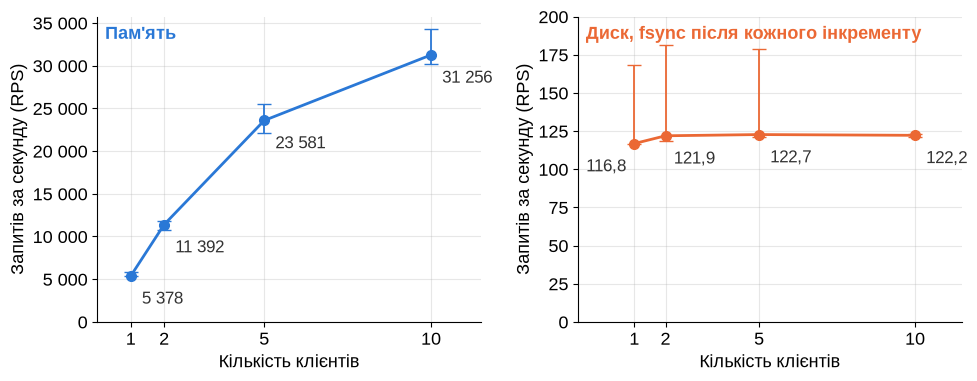

збережено Labs/01-web-counter/assets/01-task1-rps.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
panels = [(axes[0], mem, C_MEMORY, "Пам'ять", 0),
          (axes[1], disk, C_DISK, "Диск, fsync після кожного інкременту", 1)]
for ax, df, colour, label, digits in panels:
    x = df.index.to_numpy()
    med = df["rps_медіана"].to_numpy()
    err = [med - df["rps_мін"].to_numpy(), df["rps_макс"].to_numpy() - med]
    ax.errorbar(x, med, yerr=err, color=colour, marker="o", markersize=7,
                linewidth=2, capsize=5, elinewidth=1.3)
    for xi, yi in zip(x, med):
        # Для диска точки 1 і 2 стоять поруч, тож підписи розводимо в боки.
        dx, ha = {(1, 1): (-6, "right"), (1, 2): (6, "left")}.get((digits, xi), (8, "left"))
        ax.annotate(ua(yi, digits), (xi, yi), textcoords="offset points",
                    xytext=(dx, -20), ha=ha, fontsize=12, color="#333333")
    ax.set_xticks([1, 2, 5, 10])
    ax.set_xlabel("Кількість клієнтів")
    ax.set_ylabel("Запитів за секунду (RPS)")
    ax.set_ylim(0, None)
    ax.set_xlim(0, 11.5)
    ax.text(0.02, 0.97, label, transform=ax.transAxes, va="top", fontsize=13,
            fontweight="bold", color=colour)
axes[0].yaxis.set_major_formatter(lambda v, _: ua(v))
axes[1].set_ylim(0, 200)
axes[1].set_xlim(-0.8, 11.5)
fig.tight_layout()
save(fig, "01-task1-rps.png")

Лічильник у пам'яті масштабується: від 5 378 RPS для одного клієнта до
31 256 для десяти (у 5,8 раза), але від 5 до 10 клієнтів приріст лише в
1,33 раза, бо сервер і генератор ділять 8 фізичних ядер. Дисковий лічильник
тримає 116,8...122,7 RPS за будь-якої кількості клієнтів: `Mutex` на час
`fsync` робить інкременти послідовними. Довгі вуса диска для 1, 2 і 5
клієнтів дав повтор 1 (168...181 RPS), і причину видно в наступному розділі.

## 4. Затримка fsync без HTTP

`scripts/fsync-probe.py` 2000 разів виконує той самий ввід-вивід, що й
`FileCounterStore`: `pwrite` 21 байта і `fsync`, без сервера.

In [10]:
probe = pd.read_csv(DATA / "task1-fsync-probe.csv")
probe["1 / середнє, оп/с"] = (1000 / probe["mean_ms"]).round(1)
probe

,run,time,count,mean_ms,p50_ms,p99_ms,ops_per_second,"1 / середнє, оп/с"
0,1,after task1.sh and both flame graphs,2000,8.137,8.042,12.343,122.9,122.9
1,2,a few minutes later,2000,5.480,5.458,5.755,182.5,182.5
2,3,right after run 2,2000,5.472,5.463,5.803,182.7,182.7


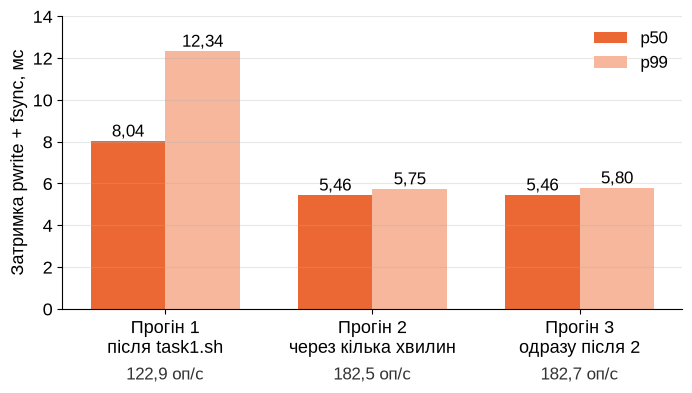

збережено Labs/01-web-counter/assets/02-fsync-probe.png


In [11]:
fig, ax = plt.subplots(figsize=(8, 3.8))
labels = ["Прогін 1\nпісля task1.sh", "Прогін 2\nчерез кілька хвилин",
          "Прогін 3\nодразу після 2"]
xs = range(len(probe))
w = 0.36
b1 = ax.bar([x - w / 2 for x in xs], probe["p50_ms"], w, color=C_DISK, label="p50")
b2 = ax.bar([x + w / 2 for x in xs], probe["p99_ms"], w, color=C_LIGHT[C_DISK], label="p99")
for bars in (b1, b2):
    for bar in bars:
        ax.annotate(ua(bar.get_height(), 2), (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                    textcoords="offset points", xytext=(0, 3), ha="center", fontsize=12)
for x, ops in zip(xs, probe["ops_per_second"]):
    ax.text(x, -0.2, f"{ua(ops, 1)} оп/с", ha="center", va="top", fontsize=12,
            transform=ax.get_xaxis_transform(), color="#333333")
ax.set_xticks(list(xs), labels)
ax.set_ylabel("Затримка pwrite + fsync, мс")
ax.set_ylim(0, 14)
ax.legend(frameon=False, loc="upper right")
ax.grid(axis="x", visible=False)
save(fig, "02-fsync-probe.png")

Затримка `fsync` на цьому SSD має два стабільні рівні: p50 близько 8,0 мс
у прогоні 1 і близько 5,5 мс у прогонах 2 і 3. Прогін 1 дає 122,9 операції
за секунду, і це майже точно медіана дискового лічильника через HTTP
(122,2 RPS для 10 клієнтів). Отже, HTTP додає до 8 мс `fsync` лише частки
мілісекунди, а RPS диска дорівнює одиниці, поділеній на затримку `fsync`.

## 5. Частина III: flame graph'и

Прогони під perf (`scripts/flamegraph.sh`, 10 клієнтів по 10 000 запитів)
теж перевіряли фінальне значення. Рисунки не перебудовуються в ноутбуці:
це готові PNG з `reports/img`, перетворені з SVG.

In [12]:
flame_runs = pd.read_csv(DATA / "task1-flamegraph-runs.csv")
assert flame_runs["correct"].all()
flame_runs

,store,clients,requests_per_client,total_requests,seconds,rps,final_value,expected,correct
0,memory,10,10000,100000,2.9187,34261.2,100000,100000,True
1,disk,10,10000,100000,600.0003,166.7,100000,100000,True


On-CPU flame graph для пам'яті: найширші стовпці належать event loop'ам і
мережевому стеку ядра (запис у сокет, `epoll_wait`), сам
`InMemoryCounterStore.increment` ледь помітний.

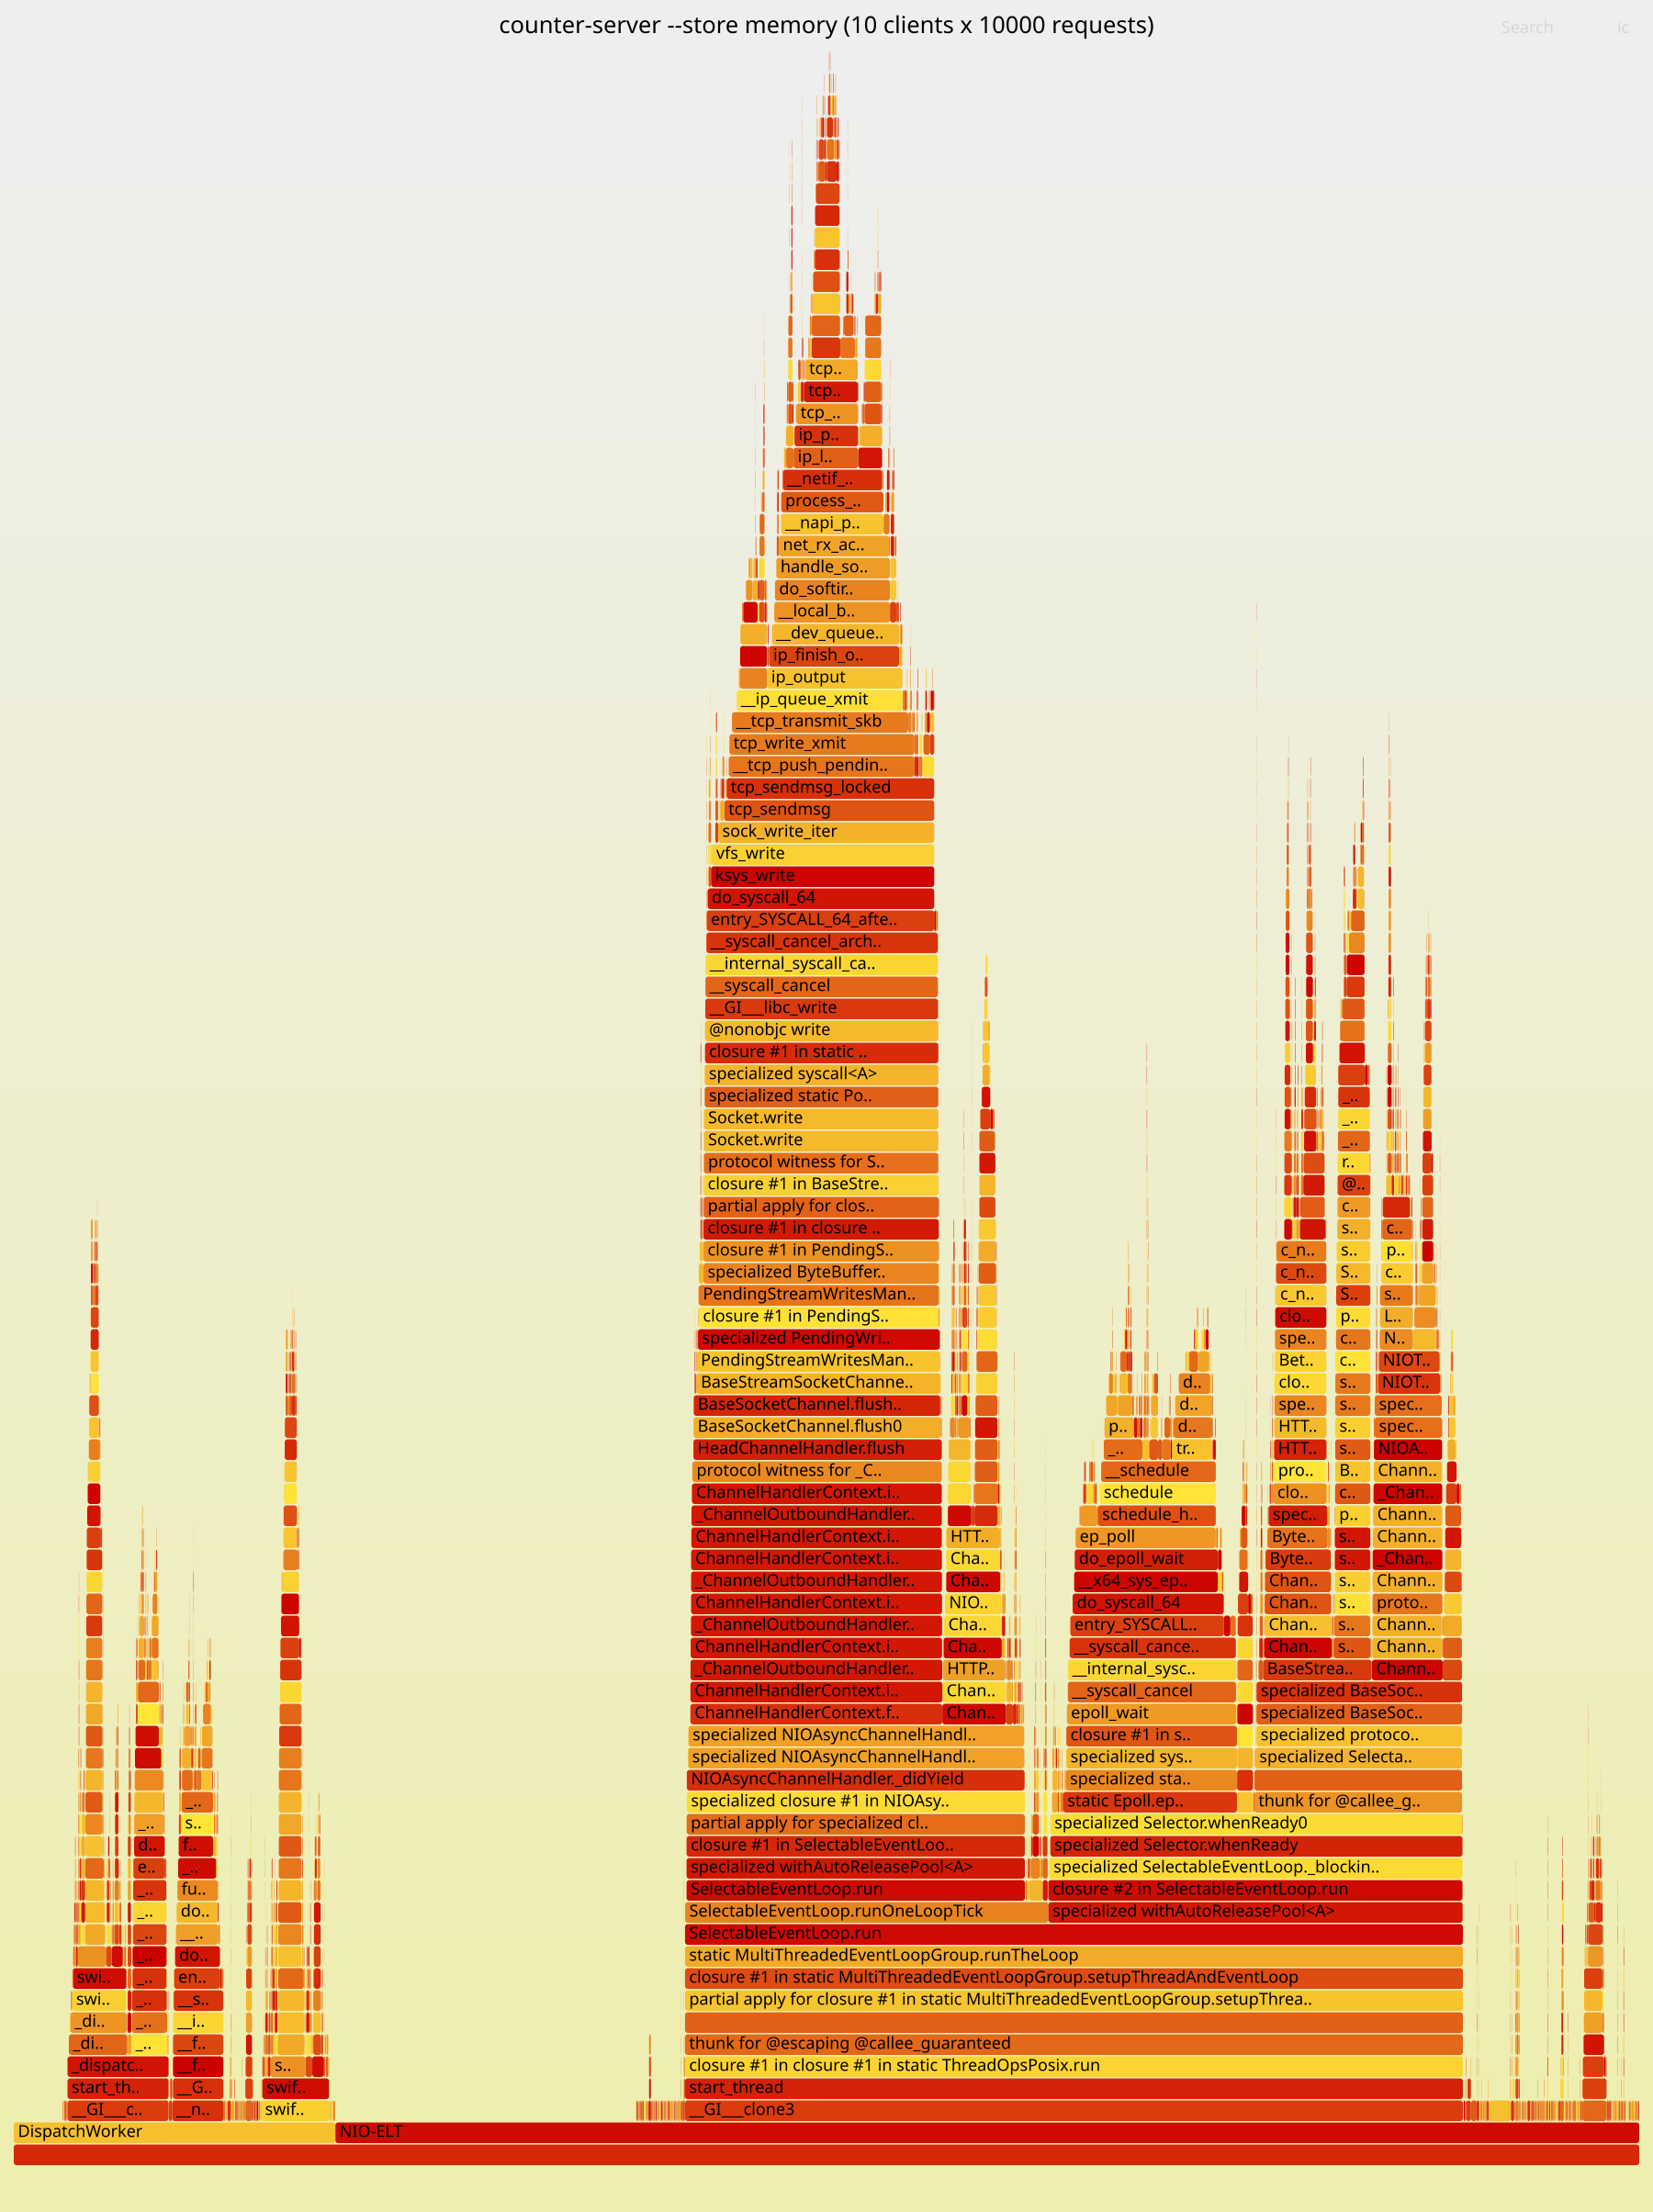

In [13]:
display(Image(filename=IMG / "flame-memory.png", width=760))

Off-CPU графік для диска показує, де потоки засинають. Кількість семплів
(засинань) беремо з кореневого вузла `all` у SVG.

,сховище,засинань,запитів,на запит
0,диск,80287,10000,8.03
1,пам'ять,31351,10000,3.14


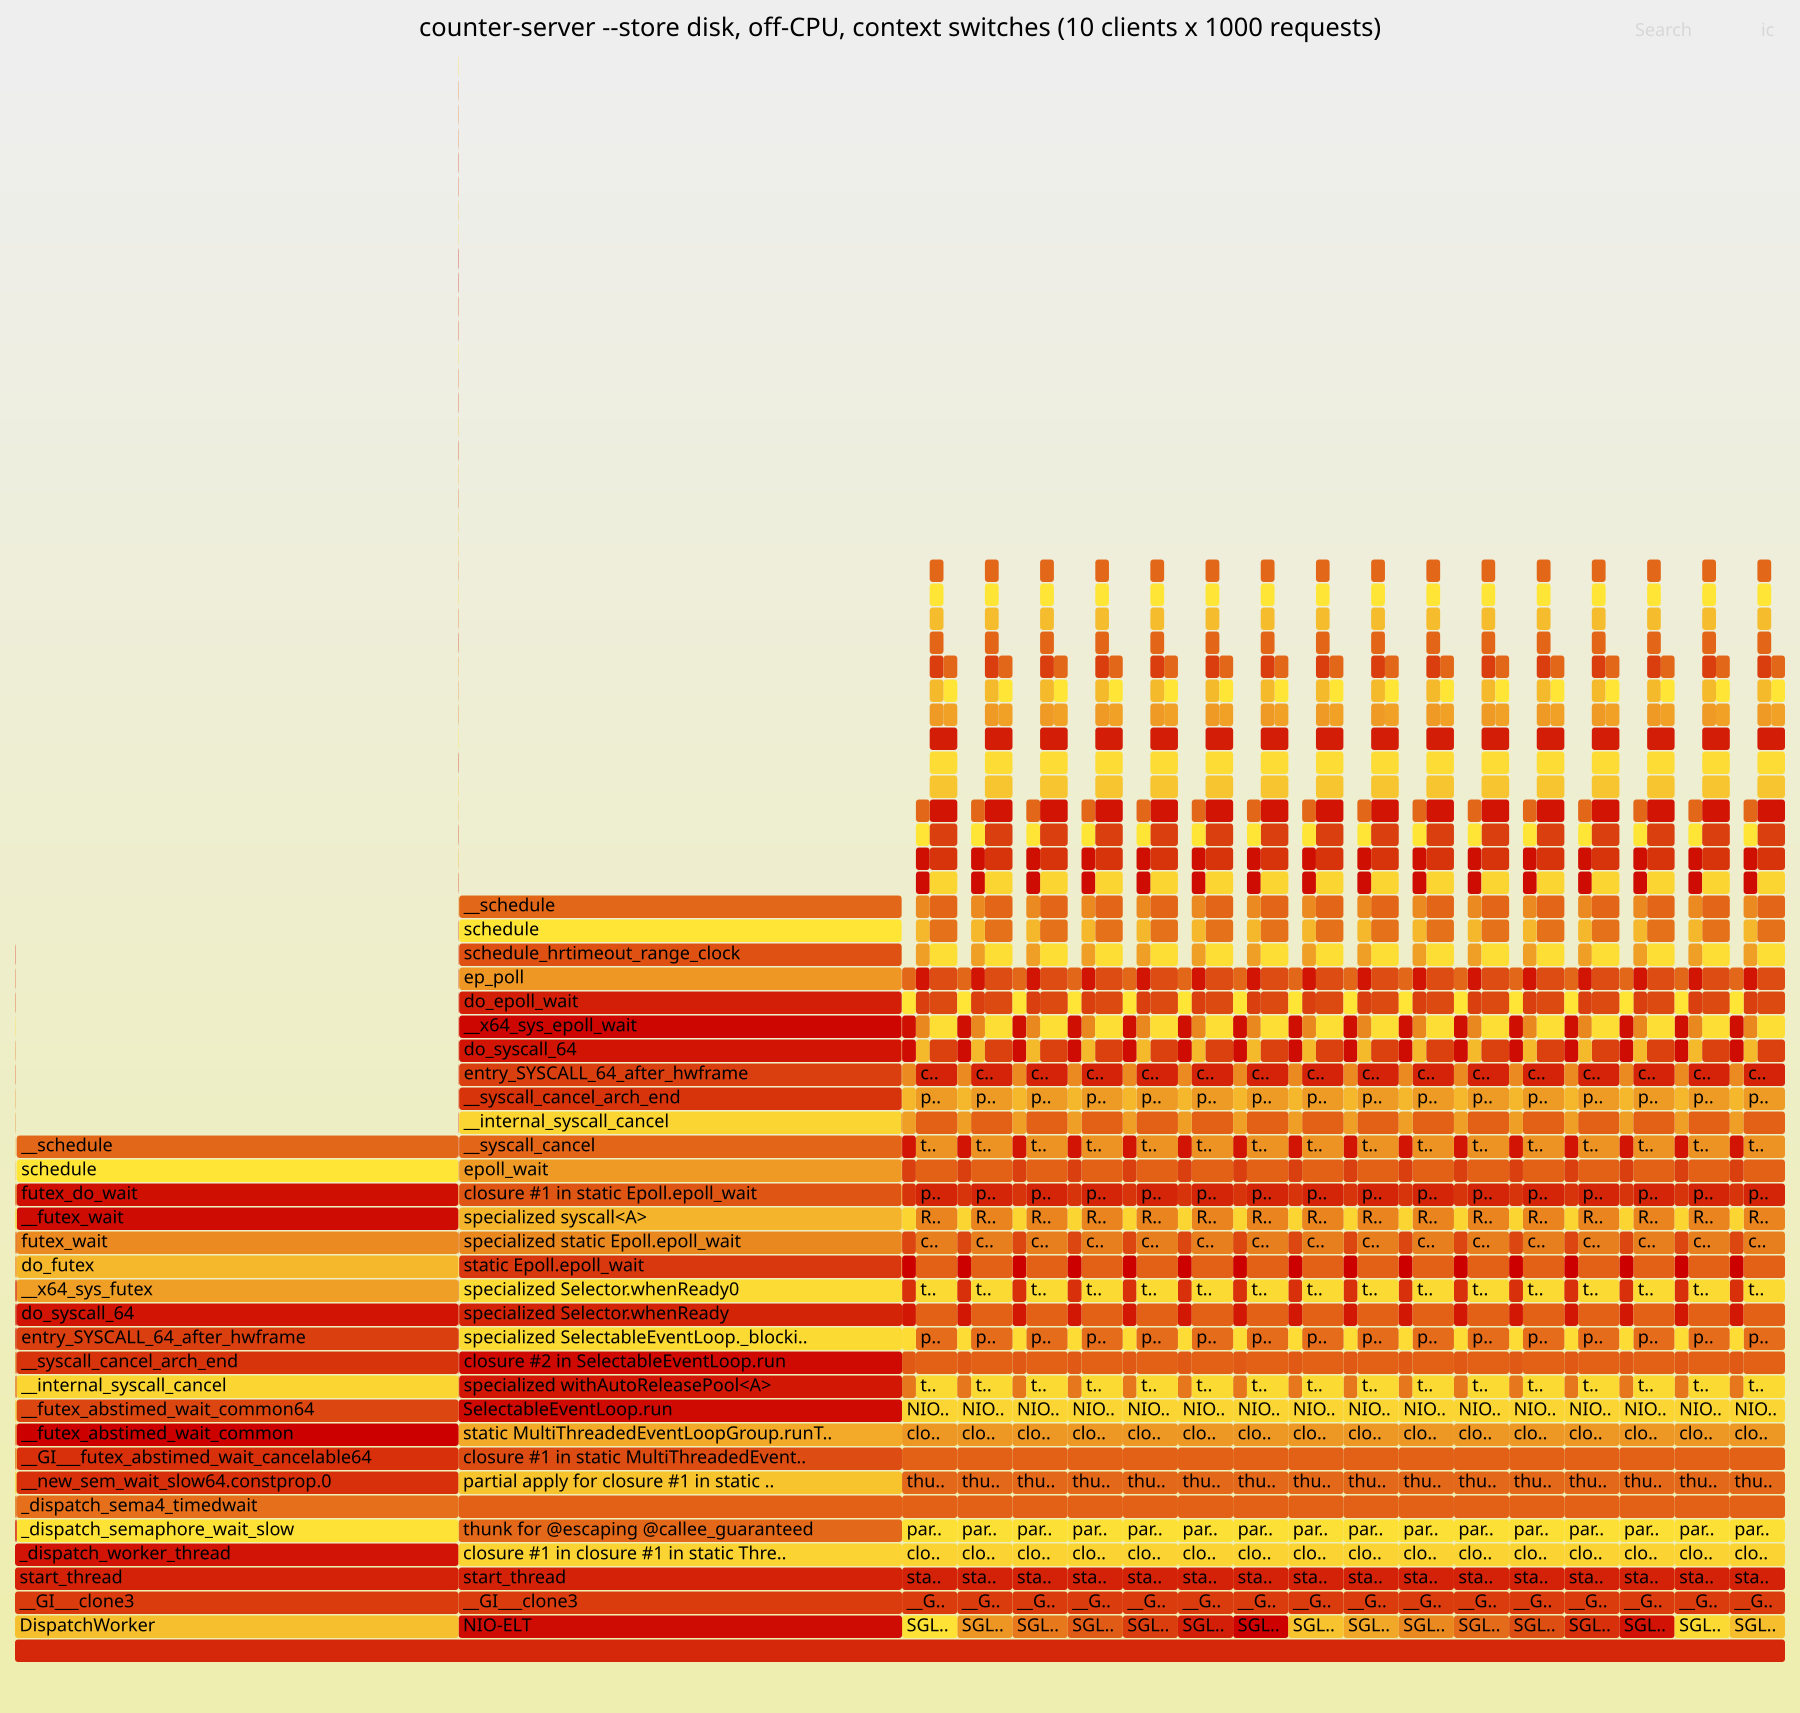

In [14]:
def offcpu_total(svg: Path) -> int:
    m = re.search(r"<title>all \(([\d,]+) samples", svg.read_text(encoding="utf-8"))
    return int(m.group(1).replace(",", ""))


offcpu = pd.DataFrame({
    "сховище": ["диск", "пам'ять"],
    "засинань": [offcpu_total(IMG / "flame-disk-offcpu.svg"),
                 offcpu_total(IMG / "flame-memory-offcpu.svg")],
    "запитів": [10_000, 10_000],
})
offcpu["на запит"] = (offcpu["засинань"] / offcpu["запитів"]).round(2)
assert offcpu["засинань"].tolist() == [80287, 31351]
display(offcpu)
display(Image(filename=IMG / "flame-disk-offcpu.png", width=760))

Дисковий сервер засинає 8 разів на запит проти 3 у пам'яті. Два з цих
засинань припадають на `fsync` (коміт журналу ext4 і запис сторінки), ще
одне на `Mutex`, за яким стоїть черга потоків пулу. On-CPU графік цього
не показує, бо сервер майже весь час простоює.

## 6. Додаткове дослідження: пам'ять, генератор і сервер

Усі варіанти міряно почергово (A, B, A, B). Сирі дані:
`reports/data/throughput-ab.csv`. Для пам'яті є дві серії по 3 запуски
(мітки з префіксом `mem-` і без нього), разом 6 запусків на варіант
(таблиця 5.2).

In [15]:
ab = pd.read_csv(DATA / "throughput-ab.csv")
assert len(ab) == 126 and ab["correct"].all()
print("запусків у серії:", len(ab), "| усі коректні:", ab["correct"].all())

mem_ab = ab[ab.experiment == "memory"].copy()
mem_ab["варіант"] = mem_ab["label"].str.removeprefix("mem-")
mem_table = (mem_ab.groupby("варіант")["rps"]
             .agg(запусків="count", медіана="median", мін="min", макс="max")
             .round(0)
             .reindex(["base-ahc", "base-nio", "handler-ahc", "handler-nio"]))
assert mem_table.loc["base-ahc", "медіана"] == 30423
assert mem_table.loc["handler-nio", "медіана"] == 98372
mem_table

запусків у серії: 126 | усі коректні: True


,запусків,медіана,мін,макс
варіант,,,,
base-ahc,6,30423.0,4500.0,37185.0
base-nio,6,64696.0,31168.0,76213.0
handler-ahc,6,33094.0,26853.0,35117.0
handler-nio,6,98372.0,91712.0,104235.0


Заміна генератора на `loadgen --engine nio` і обробка запиту прямо на
event loop'і (`--engine handler`) разом дають 98 372 RPS замість 30 423,
у 3,2 раза більше. Сам по собі handler-сервер з AsyncHTTPClient майже нічого
не дає: вузьким місцем був генератор.

## 7. Додаткове дослідження: групування комітів на диску

`--store disk-group` збирає інкременти в партію: один `pwrite` і один
`fdatasync` на всю партію, і лише потім відповіді всім запитам партії.

In [16]:
excerpt("Sources/CounterCore/GroupCommitFileCounterStore.swift",
        "let batch: (value: Int, waiters: [Waiter])?", 37)

// Sources/CounterCore/GroupCommitFileCounterStore.swift
 210 |             let batch: (value: Int, waiters: [Waiter])? = state.withLock { state in
 211 |                 if state.waiters.isEmpty {
 212 |                     state.isFlushing = false
 213 |                     return nil
 214 |                 }
 215 |                 let waiters = state.waiters
 216 |                 state.waiters.removeAll(keepingCapacity: true)
 217 |                 return (state.value, waiters)
 218 |             }
 219 |             guard let batch else {
 220 |                 return
 221 |             }
 222 |             do {
 223 |                 try CounterFile.writeRecord(batch.value, to: fd)
 224 |                 switch syncMethod {
 225 |                 case .fsync:
 226 |                     try CounterFile.sync(fd, name: "fsync") { fsync($0) }
 227 |                 case .fdatasync:
 228 |                     try CounterFile.sync(fd, name: "fdatasync") { fdatasync($0) }
 229 |        

Таблиці 5.4 і 5.5: 10 клієнтів по 2 000 запитів, по 3 запуски на варіант.

In [17]:
DISK_VARIANTS = {
    "disk-base": "disk, fsync на кожен інкремент",
    "dg-fsync-async": "disk-group, fsync",
    "dg-fdatasync-async": "disk-group, fdatasync",
    "dg-fdatasync-handler": "те саме, handler",
    "dg-fdatasync-handler-nio": "те саме, handler і генератор NIO",
}
disk_ab = (ab[ab.label.isin(DISK_VARIANTS)]
           .groupby("label")["rps"].agg(медіана="median", мін="min", макс="max")
           .reindex(list(DISK_VARIANTS)))
disk_ab.index = [DISK_VARIANTS[k] for k in disk_ab.index]
assert disk_ab["медіана"].round(1).tolist() == [147.2, 570.4, 1737.7, 1648.1, 1733.3]
display(disk_ab.round(1))

delay = ab[ab.experiment == "disk-gather-delay"].copy()
delay["затримка, мкс"] = delay["label"].str.extract(r"(\d+)$")[0].astype(int)
delay_table = (delay.groupby("затримка, мкс")["rps"]
               .agg(медіана="median", мін="min", макс="max"))
assert delay_table["медіана"].round(1).tolist() == [3405.9, 4396.8, 5438.5, 3851.8]
display(delay_table.round(1))

confirm = ab[ab.experiment == "confirm-10x10k"][["label", "store", "server_options",
                                                 "loadgen_engine", "rps", "final_value"]]
confirm

,медіана,мін,макс
"disk, fsync на кожен інкремент",147.2,114.1,158.6
"disk-group, fsync",570.4,559.8,833.0
"disk-group, fdatasync",1737.7,1661.1,2042.5
"те саме, handler",1648.1,1616.9,2653.7
"те саме, handler і генератор NIO",1733.3,1664.1,2945.8


,медіана,мін,макс
"затримка, мкс",,,
0,3405.9,2745.5,3470.9
100,4396.8,2523.0,4835.9
300,5438.5,3179.0,5495.3
1000,3851.8,3719.2,3952.1


,label,store,server_options,loadgen_engine,rps,final_value
123,confirm-dg-async-ahc,disk-group,--sync fdatasync,ahc,3269.6,100000
124,confirm-dg-delay300-handler-nio,disk-group,--sync fdatasync --engine handler --gather-del...,nio,4839.6,100000
125,confirm-pgs10-async-ahc,postgres-sharded,--pg-shards 10,ahc,3444.4,100000


Середня кількість інкрементів на один sync (4,99...9,98 у таблиці 5.5)
сервер рахує сам (`batches` і `flushedOperations` у
`GroupCommitFileCounterStore`), у CSV її немає, тому тут вона не
перераховується.

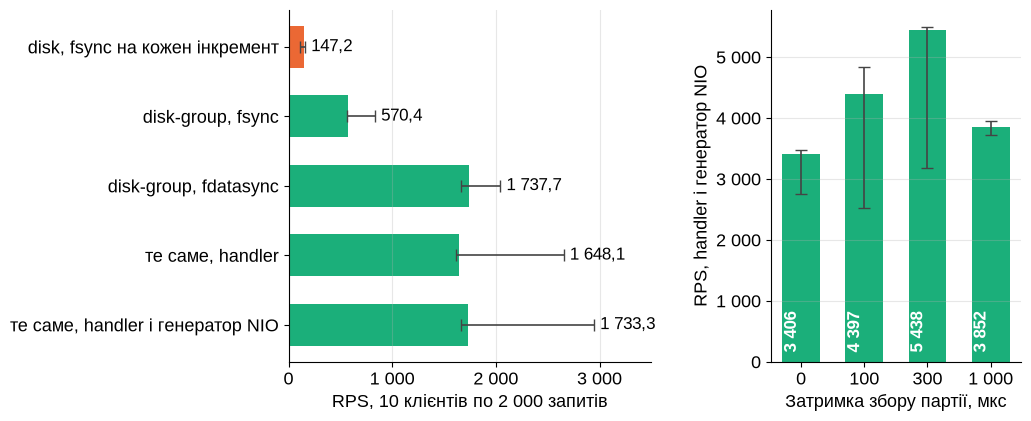

збережено Labs/01-web-counter/assets/03-disk-group-commit.png


In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10.5, 4.4),
                               gridspec_kw={"width_ratios": [1.45, 1]})
names = list(disk_ab.index)
ys = list(range(len(names)))[::-1]
colours = [C_DISK] + [C_GROUP] * (len(names) - 1)
med = disk_ab["медіана"]
ax1.barh(ys, med, color=colours, height=0.6,
         xerr=[med - disk_ab["мін"], disk_ab["макс"] - med],
         error_kw={"elinewidth": 1.2, "capsize": 4, "ecolor": "#444444"})
for y, v, top in zip(ys, med, disk_ab["макс"]):
    ax1.text(top + 60, y, ua(v, 1), va="center", fontsize=12)
ax1.set_yticks(ys, names)
ax1.set_xlabel("RPS, 10 клієнтів по 2 000 запитів")
ax1.set_xlim(0, 3500)
ax1.xaxis.set_major_formatter(lambda v, _: ua(v))
ax1.grid(axis="y", visible=False)

dmed = delay_table["медіана"]
xpos = range(len(dmed))
ax2.bar(xpos, dmed, color=C_GROUP, width=0.6,
        yerr=[dmed - delay_table["мін"], delay_table["макс"] - dmed],
        error_kw={"elinewidth": 1.2, "capsize": 4, "ecolor": "#444444"})
for x, v in zip(xpos, dmed):
    ax2.text(x - 0.15, 150, ua(v, 0), ha="center", va="bottom", fontsize=12,
             color="white", fontweight="bold", rotation=90)
ax2.set_xticks(list(xpos), [ua(d) for d in dmed.index])
ax2.set_xlabel("Затримка збору партії, мкс")
ax2.set_ylabel("RPS, handler і генератор NIO")
ax2.grid(axis="x", visible=False)
ax2.yaxis.set_major_formatter(lambda v, _: ua(v))
fig.tight_layout()
save(fig, "03-disk-group-commit.png")

Групування комітів підняло RPS диска зі 147,2 до 570,4 (у 3,9 раза), а
`fdatasync` замість `fsync` ще до 1 737,7 (у 3,0 раза). Варіанти сервера й
генератора тут нічого не змінюють, бо все визначає диск. Затримка збору
300 мкс дає найбільше, 5 438,5 RPS: партії стають більшими, а 1 000 мкс уже
забагато, бо клієнти простоюють довше, ніж економиться на sync. На повному
сценарії 10 клієнтів по 10 000 запитів отримано 3 269,6 і 4 839,6 RPS проти
122,2 в основній частині, і `/count` в обох прогонах рівно 100 000.

## 8. Додаткове дослідження: кроки за мотивами One Billion Row Challenge

`scripts/bench-engines.sh` запускає `wrk -t10 -c10 -d10s` на `/inc` і
одночасно `perf stat` на процесі сервера. Лічильники перераховано на один
запит. Крок v3 (лічильник на кожен потік) не робили: атомарний інкремент
займає 0,28 % семплів. Нижче з `reports/data/1brc-steps.csv` вибрано рядки,
з яких складено таблицю 5.6.

In [19]:
steps = pd.read_csv(DATA / "1brc-steps.csv")
STEP_ROWS = [
    ("v0", "v0-v1", "handler", "handler: NIOHTTP1, NIOAny, EventLoopFuture"),
    ("v1", "v0-v1", "raw", "raw: власний розбір байтів"),
    ("v2", "v2", "raw", "v1 і прапорці компілятора"),
    ("v4", "pin-split-cores", "raw", "v1, прив'язка до ядер"),
    ("v5", "io-uring-split", "uring", "io_uring, прив'язка до ядер"),
]
rows = []
for name, step, engine, what in STEP_ROWS:
    sel = steps[(steps.step == step) & (steps.engine == engine)]
    assert len(sel) == 3, (step, engine)
    rows.append({
        "крок": name, "що змінено": what,
        "запитів/с": sel["rps"].median(),
        "мін": sel["rps"].min(), "макс": sel["rps"].max(),
        "тактів на запит": sel["cycles_per_req"].median(),
        "інструкцій на запит": sel["instructions_per_req"].median(),
        "промахів переходів": sel["branch_misses_per_req"].median(),
        "перемикань на запит": sel["context_switches_per_req"].median(),
    })
brc = pd.DataFrame(rows).set_index("крок")
assert brc["запитів/с"].round(0).tolist() == [119914, 160499, 164659, 169888, 191269]
assert brc["інструкцій на запит"].tolist() == [78691, 44344, 40361, 41090, 32005]
brc.round(2)

,що змінено,запитів/с,мін,макс,тактів на запит,інструкцій на запит,промахів переходів,перемикань на запит
крок,,,,,,,,
v0,"handler: NIOHTTP1, NIOAny, EventLoopFuture",119914.49,119298.96,143434.86,201035.0,78691.0,1072.08,1.00
v1,raw: власний розбір байтів,160498.62,160026.85,163690.31,114182.0,44344.0,428.80,1.00
v2,v1 і прапорці компілятора,164659.27,164156.88,164677.19,106357.0,40361.0,324.63,1.00
v4,"v1, прив'язка до ядер",169888.12,169521.42,170172.85,98419.0,41090.0,361.01,0.62
v5,"io_uring, прив'язка до ядер",191268.75,187668.48,191951.09,65763.0,32005.0,140.96,0.69


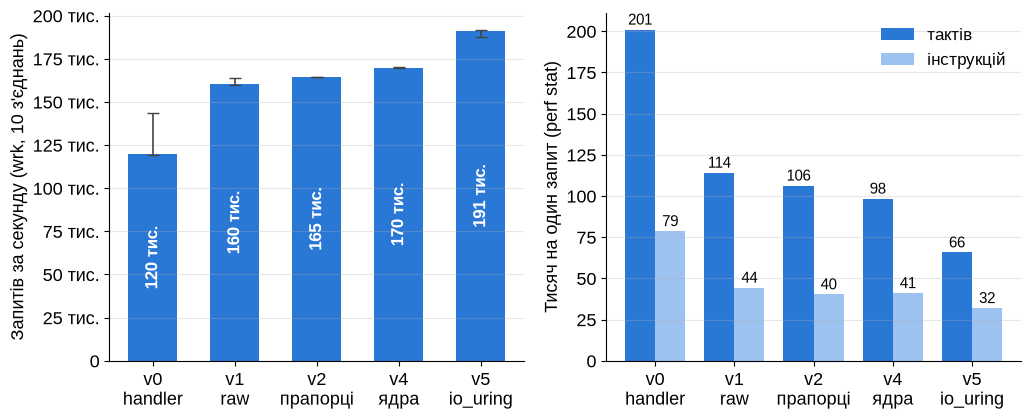

збережено Labs/01-web-counter/assets/04-1brc-steps.png


In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10.5, 4.4))
ticks = [f"{k}\n{v}" for k, v in zip(brc.index, ["handler", "raw", "прапорці",
                                                 "ядра", "io_uring"])]
xpos = list(range(len(brc)))
rps = brc["запитів/с"]
ax1.bar(xpos, rps, color=C_MEMORY, width=0.6,
        yerr=[rps - brc["мін"], brc["макс"] - rps],
        error_kw={"elinewidth": 1.2, "capsize": 4, "ecolor": "#444444"})
for x, v in zip(xpos, rps):
    ax1.text(x, v / 2, ua(v / 1000, 0) + " тис.", ha="center", va="center",
             fontsize=12, color="white", fontweight="bold", rotation=90)
ax1.set_xticks(xpos, ticks)
ax1.set_ylabel("Запитів за секунду (wrk, 10 з'єднань)")
ax1.yaxis.set_major_formatter(lambda v, _: ua(v / 1000) + " тис." if v else "0")
ax1.grid(axis="x", visible=False)

w = 0.38
cyc = brc["тактів на запит"] / 1000
ins = brc["інструкцій на запит"] / 1000
ax2.bar([x - w / 2 for x in xpos], cyc, w, color=C_MEMORY, label="тактів")
ax2.bar([x + w / 2 for x in xpos], ins, w, color=C_LIGHT[C_MEMORY], label="інструкцій")
for x, c, i in zip(xpos, cyc, ins):
    ax2.text(x - w / 2, c + 3, ua(c), ha="center", fontsize=11)
    ax2.text(x + w / 2, i + 3, ua(i), ha="center", fontsize=11)
ax2.set_xticks(xpos, ticks)
ax2.set_ylabel("Тисяч на один запит (perf stat)")
ax2.legend(frameon=False, loc="upper right")
ax2.grid(axis="x", visible=False)
fig.tight_layout()
save(fig, "04-1brc-steps.png")

Власний розбір HTTP (v1) прибрав 44 % інструкцій на запит і дав +34 %
запитів за секунду. Прапорці компілятора (v2) і прив'язка до ядер (v4)
додали ще по кілька відсотків, а io_uring (v5) зменшив такти на запит з
98 419 до 65 763 і підняв пропускну здатність до 191 269 запитів/с. Такти
на запит падають швидше, ніж росте RPS: решту часу обороту запиту займає
TCP-стек loopback у ядрі, якого ці кроки не торкаються.

## 9. Жива перевірка

**Демонстрація на зменшеному навантаженні.** Офіційні числа звіту взято
з CSV вище, а тут справжні `counter-server` і `loadgen` з
`.build/release` запускаються на порту 21421, щоб показати, що програма
працює й рахує точно. Кожен запуск сервера обгорнуто в `try/finally`:
процес зупиняється навіть після помилки, тимчасова тека з файлом лічильника
і логом видаляється. Тека створюється в `.data/` проєкту, а не в `/tmp`,
щоб `fsync` справді доходив до SSD. Логи пишуться туди ж, а не в
`reports/logs`.

In [21]:
PORT = 21421
URL = f"http://127.0.0.1:{PORT}"
BIN = ROOT / ".build" / "release"


def ensure_binaries() -> None:
    if (BIN / "counter-server").exists() and (BIN / "loadgen").exists():
        return
    subprocess.run(
        ["bash", "-lc", "source scripts/env.sh && "
         "hls_build_release --product counter-server && hls_build_release --product loadgen"],
        cwd=ROOT, check=True, timeout=900)


@contextmanager
def counter_server(store: str, *extra: str):
    """Запустити counter-server, дочекатися /count, а після блоку зупинити."""
    scratch = Path(tempfile.mkdtemp(prefix="nb01-", dir=ROOT / ".data"))
    os.environ["HLS_LOG_DIR"] = str(scratch)
    log = open(scratch / f"counter-server-{store}.log", "w")
    args = [str(BIN / "counter-server"), "--store", store, "--port", str(PORT), *extra]
    if store in ("disk", "disk-group"):
        args += ["--file", str(scratch / "counter.txt")]
    proc = subprocess.Popen(args, stdout=subprocess.DEVNULL, stderr=log)
    try:
        deadline = time.monotonic() + 10
        while True:
            if proc.poll() is not None:
                raise RuntimeError(f"counter-server завершився з кодом {proc.returncode}")
            try:
                urllib.request.urlopen(URL + "/count", timeout=1).read()
                break
            except OSError:
                if time.monotonic() > deadline:
                    raise TimeoutError("counter-server не відповів за 10 с")
                time.sleep(0.1)
        yield
    finally:
        proc.terminate()
        try:
            proc.wait(timeout=5)
        except subprocess.TimeoutExpired:
            proc.kill()
            proc.wait()
        log.close()
        shutil.rmtree(scratch, ignore_errors=True)


def loadgen(label: str, clients: int, requests: int, engine: str = "ahc") -> pd.DataFrame:
    out = subprocess.run(
        [str(BIN / "loadgen"), "--header", "--clients", str(clients),
         "--requests", str(requests), "--url", URL, "--store-label", label,
         "--engine", engine],
        capture_output=True, text=True, timeout=50)
    if out.returncode != 0:
        raise RuntimeError(f"loadgen: код {out.returncode}: {out.stderr.strip()}")
    row = pd.read_csv(io.StringIO(out.stdout))
    row.insert(1, "engine", engine)
    return row


LIVE: list[pd.DataFrame] = []
if RUN_LIVE:
    ensure_binaries()
    print("бінарні файли:", BIN.relative_to(ROOT))

бінарні файли: .build/release


### Пам'ять: 10 клієнтів по 1 000 запитів, обидва генератори

Той самий сервер (`--engine async`, як у частині I) навантажується двічі:
генератором на AsyncHTTPClient і генератором на `ChannelHandler`.

In [22]:
if RUN_LIVE:
    t0 = time.monotonic()
    with counter_server("memory"):
        mem_live = pd.concat([loadgen("memory", 10, 1000, "nio"),
                              loadgen("memory", 10, 1000, "ahc")], ignore_index=True)
    LIVE.append(mem_live)
    assert mem_live["correct"].all()
    print(f"тривалість клітинки {time.monotonic() - t0:.1f} с")
    display(mem_live)
else:
    print("RUN_LIVE = False: живий запуск пропущено")

тривалість клітинки 0.6 с


,store,engine,clients,requests_per_client,total_requests,seconds,rps,final_value,expected,correct
0,memory,nio,10,1000,10000,0.1288,77664.5,10000,10000,True
1,memory,ahc,10,1000,10000,0.3069,32588.2,10000,10000,True


### Диск: 10 клієнтів по 100 запитів

1 000 інкрементів з `fsync` кожен займають кілька секунд. Для порівняння
той самий обсяг проганяється через `--store disk-group` (групування
комітів, `fdatasync`).

In [23]:
if RUN_LIVE:
    t0 = time.monotonic()
    with counter_server("disk"):
        disk_live = loadgen("disk", 10, 100)
    with counter_server("disk-group"):
        group_live = loadgen("disk-group", 10, 100)
    disk_live = pd.concat([disk_live, group_live], ignore_index=True)
    LIVE.append(disk_live)
    assert disk_live["correct"].all()
    print(f"тривалість клітинки {time.monotonic() - t0:.1f} с")
    display(disk_live)

тривалість клітинки 6.0 с


,store,engine,clients,requests_per_client,total_requests,seconds,rps,final_value,expected,correct
0,disk,ahc,10,100,1000,5.4990,181.9,1000,1000,True
1,disk-group,ahc,10,100,1000,0.2889,3461.8,1000,1000,True


In [24]:
if RUN_LIVE:
    live = pd.concat(LIVE, ignore_index=True)
    live["fsync, мс на запит (1 / RPS)"] = (1000 / live["rps"]).where(live.store == "disk").round(2)
    assert live["correct"].all() and (live["final_value"] == live["expected"]).all()
    print(f"усі {len(live)} живі запуски коректні: /count дорівнює кількості запитів")
    display(live[["store", "engine", "clients", "requests_per_client", "seconds",
                  "rps", "final_value", "correct", "fsync, мс на запит (1 / RPS)"]])

усі 4 живі запуски коректні: /count дорівнює кількості запитів


,store,engine,clients,requests_per_client,seconds,rps,final_value,correct,"fsync, мс на запит (1 / RPS)"
0,memory,nio,10,1000,0.1288,77664.5,10000,True,NaN
1,memory,ahc,10,1000,0.3069,32588.2,10000,True,NaN
2,disk,ahc,10,100,5.4990,181.9,1000,True,5.5
3,disk-group,ahc,10,100,0.2889,3461.8,1000,True,NaN


На зменшеному навантаженні числа шумніші, ніж в офіційних серіях, але
співвідношення ті самі: пам'ять дає десятки тисяч RPS, генератор NIO
швидший за AsyncHTTPClient, диск з `fsync` дає порядку сотні RPS (одиниця,
поділена на затримку `fsync`), а групування комітів піднімає його в рази.
Значення `/count` щоразу точно дорівнює кількості запитів.

## 10. Висновки

1. Лічильник у пам'яті на `Atomic<Int>` дає 31 256 RPS (медіана для 10
   клієнтів) і масштабується в 5,8 раза від 1 до 10 клієнтів; після 5
   клієнтів приріст сповільнюється, бо сервер і генератор ділять 8 ядер.
2. Лічильник на диску з `fsync` після кожного інкременту дає 116,8...122,7
   RPS незалежно від кількості клієнтів. Це одиниця, поділена на затримку
   `fsync` (5,5 або 8,1 мс), бо `Mutex` серіалізує інкременти. Для 10
   клієнтів він у 256 разів повільніший за пам'ять.
3. Усі 24 запуски матриці, 2 прогони під perf і 126 запусків додаткової
   серії коректні: жодного втраченого інкременту.
4. Off-CPU графік показує 8 засинань на запит у дискового сервера проти 3 у
   сервера з пам'яттю, з них два всередині `fsync` і одне на `Mutex`.
5. Групування комітів з `fdatasync` підняло диск до 1 737,7 RPS на 10 × 2 000
   і до 4 839,6 RPS на повному сценарії, а покрокова оптимізація сервера в
   пам'яті підняла стелю з 119 914 до 191 269 запитів/с за `wrk`.